In [1]:
import tensorflow.keras as tf
import matplotlib.pyplot as plt
import numpy as np

In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [10]:
datagen = ImageDataGenerator(rescale=1./255)

In [15]:
train_generator = datagen.flow_from_directory("C:\\jupiter\\dataset\\dataset\\training_set",target_size=(64,64),class_mode="binary")

Found 7115 images belonging to 2 classes.


In [17]:
test_generator = datagen.flow_from_directory("C:\\jupiter\\dataset\\dataset\\test_set",target_size=(64,64),class_mode = "binary")

Found 496 images belonging to 2 classes.


In [18]:
train_generator

In [19]:
data,label = next(train_generator) #generates 32 images and their labels from out training data
data.shape

(32, 64, 64, 3)

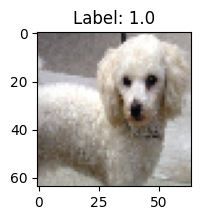

In [21]:
plt.figure(figsize=(2,2))
plt.imshow(data[18]) # from 32 image take image 
plt.title(f"Label: {label[18]}") # take label of image and show it as title of image
plt.show()

In [24]:
cnn = tf.models.Sequential()
cnn.add(tf.layers.Conv2D(filters = 32 ,kernel_size= 3 , activation="relu" , input_shape = [64,64,3]))
cnn.add(tf.layers.MaxPooling2D(pool_size = 2 , strides = 2))

cnn.add(tf.layers.Conv2D(filters = 32 , kernel_size= 3 ,activation = "relu"))
cnn.add(tf.layers.MaxPool2D(pool_size = 2 , strides = 2))

cnn.add(tf.layers.Flatten())
cnn.add(tf.layers.Dense(units = 128 , activation = "relu"))
cnn.add(tf.layers.Dense(units = 1 , activation = "sigmoid")) #outputlayer



In [26]:
cnn.compile(optimizer = "adam" , loss = "binary_crossentropy" , metrics = [ "accuracy"])


In [27]:
cnn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)                    │ (None, 62, 62, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 29, 29, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 6272)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         802,944 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 813,217 (3.10 MB)

 Trainable params: 813,217 (3.10 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
result = cnn.fit(x = train_generator , epochs = 3)

Epoch 1/3
223/223 ━━━━━━━━━━━━━━━━━━━━ 183s 798ms/step - accuracy: 0.6335 - loss: 0.6316
Epoch 2/3
223/223 ━━━━━━━━━━━━━━━━━━━━ 38s 169ms/step - accuracy: 0.7231 - loss: 0.5439
Epoch 3/3
223/223 ━━━━━━━━━━━━━━━━━━━━ 28s 127ms/step - accuracy: 0.7685 - loss: 0.4793


In [36]:
import numpy as np
from keras.preprocessing import image
from keras.utils import load_img
from keras.utils import img_to_array
new_image = load_img("C:\\jupiter\\dataset\\dataset\\single_prediction\\test.jpg" ,target_size=(64,64))

# convert the image object to array 
new_image = img_to_array(new_image)
new_image = np.expand_dims(new_image , axis = 0)
res = cnn.predict(new_image)
print(res)
#  train_set.class_indices
if res[0][0] >= 0.5:
    prediction = "dog"
else :
    prediction = "cat"

prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
[[0.]]


'cat'